# Project Title: AI-Powered Resume–Job Matching System.

## Problem Statement

In traditional recruitment systems, resume screening is performed manually, which is time-consuming, inconsistent, and prone to human bias. Recruiters often face challenges in efficiently matching candidate skills with job requirements due to the unstructured nature of resume data.
Moreover, automated systems without fairness evaluation may unintentionally favor certain demographic groups, leading to biased hiring decisions.

Therefore, there is a need for an intelligent, efficient, and fairness-aware system that can automatically match resumes with job descriptions while ensuring unbiased and ethical recruitment.

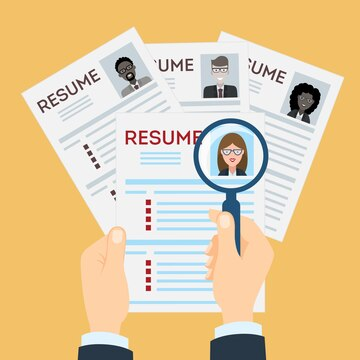 

## Project Abstract

This project presents an AI-powered Resume–Job Matching System that automates the recruitment screening process using Natural Language Processing (NLP) and Machine Learning techniques. The system extracts and cleans textual data from resumes and job descriptions, converts them into numerical representations using TF-IDF vectorization, and computes similarity scores using cosine similarity to determine the best job matches.
The platform ranks job roles based on relevance scores and provides real-time job openings using API integration. Additionally, the system incorporates fairness-aware AI techniques to evaluate demographic parity and detect potential bias in recommendations.
Developed using Python, spaCy, Scikit-learn, Pandas, and Streamlit, the system enhances recruitment efficiency, reduces manual effort, improves matching accuracy, and promotes responsible AI-driven hiring.

## Project Objectives

1) To design an automated resume screening system using NLP techniques.
2) To extract skills and important features from resumes and job descriptions.
3) To implement TF-IDF vectorization for text-to-numerical transformation.
4) To calculate similarity between resumes and job roles using cosine similarity.
5) To rank job roles based on matching scores.
6) To integrate real-time job listings using API services.
7) To evaluate fairness using bias detection techniques such as demographic parity.
8) To build an interactive Streamlit-based user interface for recruiters and candidates.

## Project Goals

1) Reduce manual resume screening time.
2) Improve accuracy in candidate-job matching.
3) Ensure unbiased and fair hiring recommendations.
4) Provide real-time job suggestions to users.
5) Build a scalable AI-based recruitment solution.

## Project Outcomes

After successful implementation:

1) The system can analyze resumes automatically.
2) It generates top 5 matching job roles with similarity scores.
3) It fetches real-time job openings using RapidAPI integration.
4) It improves recruitment speed and efficiency.
5) It supports ethical AI hiring practices.
6) It provides an interactive and user-friendly dashboard.

## Conclusion

The AI Resume–Job Matching System demonstrates how Natural Language Processing and Machine Learning can significantly enhance the recruitment process. By converting unstructured resume data into structured numerical representations and applying similarity-based matching, the system effectively recommends relevant job roles.
Furthermore, incorporating fairness-aware evaluation ensures that the recruitment process remains ethical and unbiased. The project highlights the practical application of AI in HR technology and provides a scalable framework for intelligent hiring systems.

## Future Scope

1) Integration of Deep Learning models (BERT, Transformers) for improved semantic understanding.
2) Advanced bias mitigation algorithms for stronger fairness guarantees.
3) Resume ranking for recruiters (candidate recommendation system).
4) Integration with LinkedIn or company career portals.
5) Multi-language resume processing support
6) AI-based resume improvement suggestions.
7) Cloud deployment for enterprise-level scalability.

In [1]:
!pip install spacy

Defaulting to user installation because normal site-packages is not writeable


#### This installs the spaCy library in the Python environment.
#### spaCy is used for Natural Language Processing tasks such as text cleaning, tokenization, and lemmatization in the project.

In [2]:
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 10.7 MB/s eta 0:00:02
     ---------- ----------------------------- 3.4/12.8 MB 8.8 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 6.3 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 5.5 MB/s eta 0:00:02
     --------------- ------------------------ 5.0/12.8 MB 4.7 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 4.5 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 4.6 MB/s eta 0:00:02
     -------------------------- ------------- 8.4/12.8 MB 4.8 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 5.0 MB/s eta 0:00:01
     ----------------------------------- ---- 11.3/12.8 MB 5.2 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.8 MB

#### This command downloads the English language model en_core_web_sm for spaCy.
#### The model enables text processing features like part-of-speech tagging, lemmatization, and entity recognition.

In [3]:
import pandas as pd
import numpy as np
import re

# NLP
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

1) pandas is used for loading and manipulating structured datasets.
2) numpy is used for numerical operations and array handling.
3) re is used for text cleaning using regular expressions.
4) spacy is used for Natural Language Processing tasks like tokenization and lemmatization.
5) TfidfVectorizer converts text data into numerical vectors.
6) cosine_similarity calculates similarity between resume and job vectors.
7) matplotlib and seaborn are used for data visualization

In [4]:
resume_df = pd.read_csv("resume_dataset.csv")

job_df = pd.read_csv("job_dataset.csv")

pd.read_csv() reads the resume dataset from a CSV file and stores it in a DataFrame named resume_df.

The job dataset is similarly loaded into a DataFrame named job_df.

This step prepares the datasets for further processing and analysis.

In [5]:
resume_df.head()

,Name,Age,Gender,Education_Level,Field_of_Study,Degrees,Institute_Name,Graduation_Year,Experience_Years,Current_Job_Title,Previous_Job_Titles,Skills,Certifications,Target_Job_Description
0,Akash Pillai,30,Non-Binary,Master's,Cybersecurity,Master's in Cybersecurity,University of Pennsylvania,2025,0,NaN,NaN,"Node.js, JavaScript, Deep Learning, Statistics...",Google Cloud Professional,Seeking a challenging role as a Software Devel...
1,Charlotte Taylor,27,Non-Binary,Bachelor's,Electronics Engineering,Bachelor's in Electronics Engineering,Pune University,2019,5,Cybersecurity Engineer,NaN,"Spark, Kubernetes, Terraform, Natural Language...",TensorFlow Developer Certificate,Targeting a Cybersecurity Engineer position to...
2,James Zhou,45,Male,Bachelor's,Computer Science,Bachelor's in Computer Science,Amity University,2023,2,Prompt Engineer,NaN,"Data Analysis, Node.js, Machine Learning, Linu...","Microsoft Azure Fundamentals, Cisco Certified ...",Targeting a Prompt Engineer position to utiliz...
3,Amelia Thomas,28,Male,Master's,Information Technology,Master's in Information Technology,University of Pennsylvania,2023,2,AI Engineer,NaN,"Docker, Kubernetes, Blockchain, Spark",NaN,Targeting a Data Scientist position where I ca...
4,Amanda Jain,42,Non-Binary,Master's,Electronics Engineering,Master's in Electronics Engineering,University of Toronto,2023,2,Cybersecurity Engineer,NaN,"Statistics, Blockchain, Kubernetes, Cybersecurity",NaN,Looking for an opportunity as a Prompt Enginee...


head() displays the first five rows of the resume dataset.

It helps verify that the dataset is loaded correctly.

It provides an overview of the dataset structure and column names.

In [6]:
job_df.head()

,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
0,NET-F-001,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Framework; .NET Core f...,Assist in coding and debugging applications; L...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
1,NET-F-002,.NET Developer,Fresher,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTM...,Write simple C# programs under guidance; Suppo...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
2,NET-F-003,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...,Contribute to development of small modules; As...,.NET; C#; ASP.NET MVC; SQL Server; Entity Fram...
3,NET-F-004,.NET Developer,Fresher,0-1,C#; .NET Framework; ASP.NET basics; SQL Server...,Support in software design documentation; Assi...,.NET; C#; SQL Server; Entity Framework; ASP.NET
4,NET-F-005,.NET Developer,Fresher,0-1,C#; ASP.NET; MVC; Entity Framework basics; SQL...,Learn to design and build ASP.NET applications...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...


#### head() displays the first five rows of the job dataset

In [7]:
print("Resume dataset shape:", resume_df.shape)
print("Job dataset shape:", job_df.shape)

Resume dataset shape: (1200, 14)
Job dataset shape: (1068, 7)


#### .shape returns the number of rows and columns in the dataset.
#### It helps understand the size of both resume and job datasets.

In [8]:
print("Resume columns:")
print(resume_df.columns)

print("\nJob columns:")
print(job_df.columns)

Resume columns:
Index(['Name', 'Age', 'Gender', 'Education_Level', 'Field_of_Study', 'Degrees',
       'Institute_Name', 'Graduation_Year', 'Experience_Years',
       'Current_Job_Title', 'Previous_Job_Titles', 'Skills', 'Certifications',
       'Target_Job_Description'],
      dtype='object')

Job columns:
Index(['JobID', 'Title', 'ExperienceLevel', 'YearsOfExperience', 'Skills',
       'Responsibilities', 'Keywords'],
      dtype='object')


#### .columns displays all column names in the dataset.

#### Resume Dataset Column Description

1) Name – Candidate’s full name.
2) Age – Candidate’s age in years.
3) Gender – Gender of the candidate.
4) Education_Level – Highest education qualification (e.g., Bachelor’s, Master’s).
5) Field_of_Study – Academic specialization (e.g., Computer Science, Electronics).
6) Degrees – Specific degree obtained (e.g., B.Tech, M.Sc).
7) Institute_Name – Name of the university or college attended.
8) Graduation_Year – Year in which the candidate completed graduation.
9) Experience_Years – Total years of work experience.
10) Current_Job_Title – Present job position of the candidate
11) Previous_Job_Titles – List of previous job roles held.
12) Skills – Technical and professional skills possessed by the candidate.
13) Certifications – Professional certifications earned.
14) Target_Job_Description – Job role or description the candidate is aiming for

#### Job Dataset Column Description

1) JobID – Unique identification number for each job posting.
2) Title – Name of the job position (e.g., .NET Developer).
3) ExperienceLevel – Required experience level (e.g., Fresher, Mid-level).
4) YearsOfExperience – Required years of work experience for the job
5) Skills – Required technical skills for the job role.
6) Responsibilities – Key duties and responsibilities of the job.
7) Keywords – Important keywords related to the job profile.

In [9]:
# Check missing values
print(resume_df.isnull().sum())
print(job_df.isnull().sum())

Name                        0
Age                         0
Gender                      0
Education_Level             0
Field_of_Study              0
Degrees                     0
Institute_Name              0
Graduation_Year             0
Experience_Years            0
Current_Job_Title         441
Previous_Job_Titles       914
Skills                      0
Certifications            319
Target_Job_Description      0
dtype: int64
JobID                0
Title                1
ExperienceLevel      0
YearsOfExperience    0
Skills               0
Responsibilities     0
Keywords             0
dtype: int64


#### isnull() checks for missing (null) values in the dataset.
#### sum() counts the total number of missing values in each column.

In [10]:
resume_df['Current_Job_Title'] = resume_df['Current_Job_Title'].fillna('')
resume_df['Previous_Job_Titles'] = resume_df['Previous_Job_Titles'].fillna('')
resume_df['Certifications'] = resume_df['Certifications'].fillna('')

#### fillna('') replaces missing values with an empty string.
#### It prevents errors during text processing and vectorization. This ensures all text columns contain valid string data.

In [11]:
job_df['Title'] = job_df['Title'].fillna('')

#### Missing values in the Title column are replaced with an empty string.

In [12]:
# Check missing values
print(resume_df.isnull().sum())
print(job_df.isnull().sum())

Name                      0
Age                       0
Gender                    0
Education_Level           0
Field_of_Study            0
Degrees                   0
Institute_Name            0
Graduation_Year           0
Experience_Years          0
Current_Job_Title         0
Previous_Job_Titles       0
Skills                    0
Certifications            0
Target_Job_Description    0
dtype: int64
JobID                0
Title                0
ExperienceLevel      0
YearsOfExperience    0
Skills               0
Responsibilities     0
Keywords             0
dtype: int64


#### This step re-checks the dataset for missing values after handling them. It confirms that all null values have been successfully removed or replaced.

In [13]:
resume_df['resume_text'] = (
    resume_df['Skills'] + ' ' +
    resume_df['Target_Job_Description'] + ' ' +
    resume_df['Previous_Job_Titles'] + ' ' +
    resume_df['Certifications']
)

#### A new column resume_text is created by combining multiple important text fields. It merges Skills, Target Job Description, Previous Job Titles, and Certifications into one text string.

In [14]:
resume_df[['resume_text']].head()

,resume_text
0,"Node.js, JavaScript, Deep Learning, Statistics..."
1,"Spark, Kubernetes, Terraform, Natural Language..."
2,"Data Analysis, Node.js, Machine Learning, Linu..."
3,"Docker, Kubernetes, Blockchain, Spark Targetin..."
4,"Statistics, Blockchain, Kubernetes, Cybersecur..."


#### This displays the first five rows of the newly created resume_text column

In [15]:
job_df['job_text'] = (
    job_df['Title'] + ' ' +
    job_df['Skills'] + ' ' +
    job_df['Responsibilities'] + ' ' +
    job_df['Keywords']
)

#### A new column job_text is created by combining important job-related fields. It merges Title, Skills, Responsibilities, and Keywords into one text string.

In [16]:
job_df[['job_text']].head()

,job_text
0,.NET Developer C#; VB.NET basics; .NET Framewo...
1,.NET Developer C#; .NET Framework basics; ASP....
2,.NET Developer C#; VB.NET basics; .NET Core; A...
3,.NET Developer C#; .NET Framework; ASP.NET bas...
4,.NET Developer C#; ASP.NET; MVC; Entity Framew...


#### This displays the first five rows of the job_text column.

In [17]:
nlp = spacy.load("en_core_web_sm")

#### This loads the pre-trained English language model of spaCy. It enables text processing features like tokenization and lemmatization

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    doc = nlp(text)
    tokens = [
        token.lemma_ 
        for token in doc 
        if not token.is_stop and token.is_alpha
    ]
    
    return " ".join(tokens)

#### This function cleans and preprocesses text data. It converts text to lowercase and removes special characters. spaCy is used to tokenize and lemmatize words. Stop words and non-alphabetic words are removed.

In [19]:
resume_df['clean_resume_text'] = resume_df['resume_text'].apply(clean_text)

#### The clean_text() function is applied to the resume_text column. A new column clean_resume_text is created with processed text.

In [20]:
resume_df[['resume_text', 'clean_resume_text']].head()

,resume_text,clean_resume_text
0,"Node.js, JavaScript, Deep Learning, Statistics...",node js javascript deep learning statistic sql...
1,"Spark, Kubernetes, Terraform, Natural Language...",spark kubernete terraform natural language pro...
2,"Data Analysis, Node.js, Machine Learning, Linu...",datum analysis node js machine learn linux jen...
3,"Docker, Kubernetes, Blockchain, Spark Targetin...",docker kubernete blockchain spark target data ...
4,"Statistics, Blockchain, Kubernetes, Cybersecur...",statistic blockchain kubernete cybersecurity l...


#### This displays both original and cleaned resume text.

In [21]:
job_df['clean_job_text'] = job_df['job_text'].apply(clean_text)

#### The clean_text() function is applied to the job_text column. A new column clean_job_text is created with processed job text.

In [22]:
job_df[['job_text', 'clean_job_text']].head()

,job_text,clean_job_text
0,.NET Developer C#; VB.NET basics; .NET Framewo...,net developer c vb net basic net framework net...
1,.NET Developer C#; .NET Framework basics; ASP....,net developer c net framework basic asp net ra...
2,.NET Developer C#; VB.NET basics; .NET Core; A...,net developer c vb net basic net core asp net ...
3,.NET Developer C#; .NET Framework; ASP.NET bas...,net developer c net framework asp net basic sq...
4,.NET Developer C#; ASP.NET; MVC; Entity Framew...,net developer c asp net mvc entity framework b...


#### This displays both original and cleaned job text.

In [23]:
resume_df['resume_length'] = resume_df['clean_resume_text'].apply(len)

resume_df['resume_length'].describe()

count    1200.000000
mean      234.550000
std        45.580648
min       121.000000
25%       202.000000
50%       233.500000
75%       266.000000
max       393.000000
Name: resume_length, dtype: float64

#### A new column resume_length is created to store the length of cleaned resume text.
#### describe() provides statistical summary like mean, min, max, and standard deviation.

In [24]:
job_df['job_length'] = job_df['clean_job_text'].apply(len)

job_df['job_length'].describe()

count    1068.000000
mean      479.724719
std       166.911189
min       161.000000
25%       329.000000
50%       479.000000
75%       616.000000
max      1077.000000
Name: job_length, dtype: float64

#### A new column job_length stores the length of cleaned job text. It measures the number of characters in each job description.
#### describe() gives statistical summary of job text lengths.

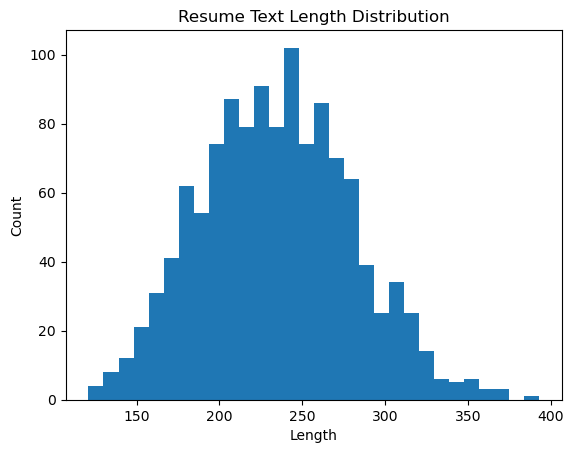

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(resume_df['resume_length'], bins=30)
plt.title("Resume Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

matplotlib.pyplot is imported for data visualization.

plt.hist() creates a histogram of resume text lengths.

bins=30 divides the data into 30 intervals.

The title and axis labels are added for clarity.

plt.show() displays the graph.

#### The graph shows that the majority of resumes have moderate and similar text lengths, which suggests consistency in resume content size across the dataset. Most resumes are concentrated between 200 to 280 characters, indicating a common resume length range.

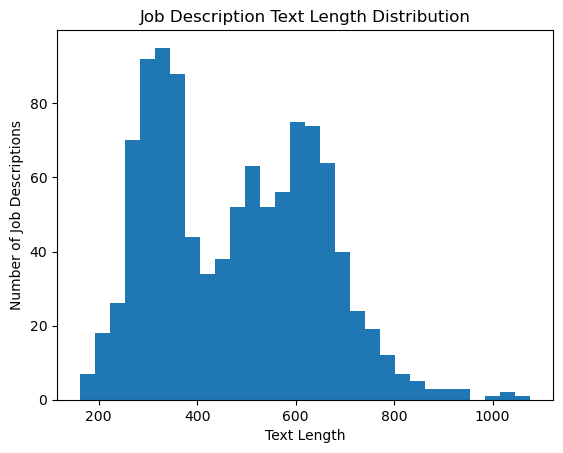

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(job_df['job_length'], bins=30)
plt.title("Job Description Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Number of Job Descriptions")
plt.show()

#### The graph shows that job descriptions are generally longer and more detailed compared to resumes. Most job descriptions fall between 300 to 700 characters.

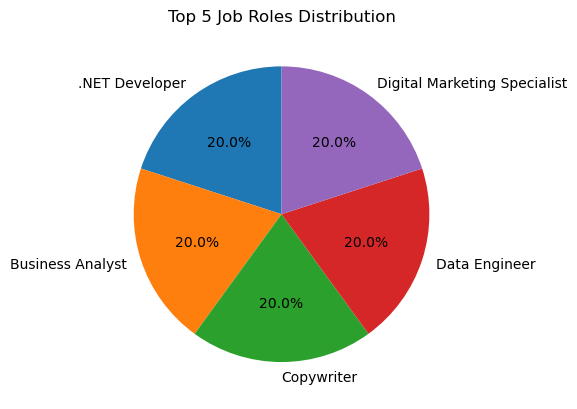

In [27]:
top_jobs = job_df['Title'].value_counts().head(5)

plt.figure()
plt.pie(
    top_jobs,
    labels=top_jobs.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Top 5 Job Roles Distribution")
plt.show()

value_counts() counts the frequency of each job title in the dataset.

head(5) selects the top 5 most frequent job roles.

plt.pie() creates a pie chart to visualize their distribution.

labels=top_jobs.index displays job role names on the chart.

autopct='%1.1f%%' shows percentage values on each slice.

startangle=90 rotates the chart for better visual alignment.

plt.show() displays the pie chart.

#### The graph shows a balanced distribution among the most common job roles, indicating diversity in job postings. This helps ensure that the resume-job matching system is trained on varied job categories rather than being biased toward a single role.

In [28]:
# Remove rows with missing or empty job titles
job_df = job_df[job_df['Title'].notna()]
job_df = job_df[job_df['Title'].str.strip() != '']

#### notna() removes rows where the job title is missing (null values).
#### str.strip() != "" removes rows where the job title is empty or contains only spaces.
#### This ensures that only valid job titles remain in the dataset.

In [29]:
job_role_df = job_df.groupby('Title').agg({
    'clean_job_text': ' '.join
}).reset_index()

#### groupby('Title') groups all rows with the same job title.
#### ' '.join combines all cleaned job text under each job title into one single string.
#### reset_index() converts the grouped data back into a normal DataFrame.

In [30]:
job_role_df.head()

,Title,clean_job_text
0,.NET Developer,net developer c vb net basic net framework net...
1,AI Engineer - Experienced,ai engineer experience python java c r deep le...
2,AI Engineer - Fresher,ai engineer fresher python java c r supervise ...
3,AI Prompt Engineer,ai prompt engineer python basic javascript bas...
4,AR/VR Developer,ar vr developer c basic c basic javascript bas...


In [31]:
job_role_df.head(15)

,Title,clean_job_text
0,.NET Developer,net developer c vb net basic net framework net...
1,AI Engineer - Experienced,ai engineer experience python java c r deep le...
2,AI Engineer - Fresher,ai engineer fresher python java c r supervise ...
3,AI Prompt Engineer,ai prompt engineer python basic javascript bas...
4,AR/VR Developer,ar vr developer c basic c basic javascript bas...
5,Android App Developer Trainee,android app developer trainee kotlin java andr...
6,Android Architect,android architect kotlin java android studio m...
7,Android Developer,android developer java kotlin android studio j...
8,Android Developer Intern,android developer intern java kotlin android s...
9,Android Developer Trainee,android developer trainee java kotlin android ...


In [32]:
job_role_df.shape

(218, 2)

#### .shape returns the number of rows and columns in job_role_df. It shows the total number of unique job roles and features available.

In [33]:
combined_corpus = pd.concat(
    [resume_df['clean_resume_text'], job_role_df['clean_job_text']],
    axis=0
)

#### pd.concat() combines cleaned resume text and cleaned job text into one dataset. axis=0 stacks them vertically.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
tfidf.fit(combined_corpus)

TfidfVectorizer(max_features=3000)

#### TfidfVectorizer converts text into numerical feature vectors. max_features=3000 limits the vocabulary size to 3000 important words.
#### fit() learns vocabulary and word importance from the combined corpus.
#### This prepares the model for transforming text into vectors.

In [35]:
resume_tfidf = tfidf.transform(resume_df['clean_resume_text'])
job_role_tfidf = tfidf.transform(job_role_df['clean_job_text'])

print(resume_tfidf.shape)
print(job_role_tfidf.shape)

(1200, 1562)
(218, 1562)


#### transform() converts text into TF-IDF numerical vectors.
#### resume_tfidf contains vector representation of resumes.
#### job_role_tfidf contains vector representation of job roles.
#### Both are now in mathematical form for similarity comparison.

#### 1200 resumes and 218 job roles are converted into vectors.
#### 1562 represents the number of unique important words (features).

In [36]:
import pickle

# Save TF-IDF Vectorizer
with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save Job Role TF-IDF Matrix
with open("job_role_tfidf.pkl", "wb") as f:
    pickle.dump(job_role_tfidf, f)

# Save Job Role DataFrame
with open("job_role_df.pkl", "wb") as f:
    pickle.dump(job_role_df, f)

print("Pickle files created successfully!")

Pickle files created successfully!


In [37]:
import os
os.listdir()

['.idea',
 '.ipynb_checkpoints',
 '.venv',
 'Ai resume flow.docx',
 'Ai resume.docx',
 'AI_Resume_Job_Matching_Project.ipynb',
 'app.py',
 'app1.py',
 'app2.py',
 'app3.py',
 'job_dataset.csv',
 'job_role_df.pkl',
 'job_role_tfidf.pkl',
 'resume6.jpg',
 'resume_dataset.csv',
 'tfidf.pkl']

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(resume_tfidf, job_role_tfidf)
similarity_matrix.shape

(1200, 218)

#### cosine_similarity() calculates similarity between resume and job vectors. It measures the angle between two vectors (range: 0 to 1). A higher value indicates better matching.

In [39]:
def recommend_jobs(resume_index, top_n=5):
    scores = similarity_matrix[resume_index]
    top_indices = scores.argsort()[::-1][:top_n]

    recommendations = []
    for idx in top_indices:
        recommendations.append({
            'Job_Title': job_role_df.iloc[idx]['Title'],
            'Match_Score': scores[idx]
        })

    return pd.DataFrame(recommendations)

#### The function recommend_jobs() generates job recommendations for a given resume. resume_index selects a specific resume from the similarity matrix. scores retrieves similarity scores between that resume and all job roles. argsort()[::-1] sorts the scores in descending order (highest match first). top_n selects the top matching job roles. The function returns a DataFrame containing job titles and their match scores.

In [40]:
recommend_jobs(0, top_n=10)

,Job_Title,Match_Score
0,Software Developer - Experienced,0.282001
1,Web Developer,0.273788
2,Full Stack Developer - Experienced,0.221116
3,Full Stack Developer - Entry Level,0.215655
4,JavaScript Developer,0.209526
5,Software Developer - Entry Level,0.205257
6,Software Engineer - Entry Level,0.191172
7,Software Engineer - Experienced,0.162608
8,Data Scientist - Experienced,0.160973
9,Backend Developer - Entry Level,0.157816


#### This generates the top 10 job recommendations for the first resume (index 0). It displays job titles ranked by similarity score.

In [41]:
import numpy as np

np.random.seed(42)

resume_df['Gender'] = np.random.choice(
    ['Male', 'Female'],
    size=len(resume_df)
)

#### np.random.seed(42) ensures reproducibility of random results. A new column Gender is created in the resume dataset. Gender values are randomly assigned as Male or Female. This is used for fairness evaluation purposes.

In [42]:
# Maximum similarity score for each resume
resume_df['max_match_score'] = similarity_matrix.max(axis=1)

# Select top 20% candidates
threshold = np.percentile(resume_df['max_match_score'], 80)

resume_df['Selected'] = resume_df['max_match_score'] >= threshold

#### max(axis=1) finds the highest similarity score for each resume. It represents the best job match score per candidate.

#### The 80th percentile score is calculated as a selection threshold. Only candidates with scores above this threshold are selected. This simulates shortlisting the top 20% candidates.

In [43]:
demographic_parity = resume_df.groupby('Gender')['Selected'].mean()
demographic_parity

Gender
Female    0.21202
Male      0.18802
Name: Selected, dtype: float64

#### Data is grouped by Gender. The mean of Selected gives the selection rate for each gender. This measures fairness in candidate selection.

#### 21.2% of female candidates were selected. 18.8% of male candidates were selected. There is a small difference in selection rates.

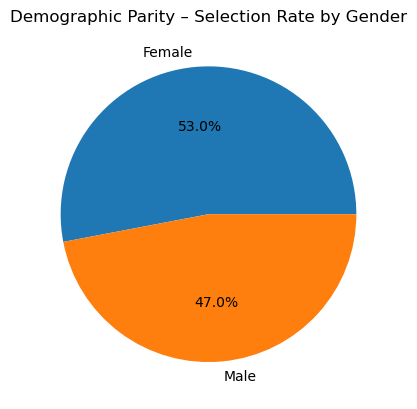

In [44]:
import matplotlib.pyplot as plt

demographic_parity.plot(kind='pie', autopct='%1.1f%%')
plt.title("Demographic Parity – Selection Rate by Gender")
plt.ylabel("")
plt.show()

#### demographic_parity.plot(kind='pie') creates a pie chart of selection rates grouped by gender. autopct='%1.1f%%' displays percentage values on each slice. The title describes the purpose of the chart. plt.ylabel("") removes the default y-axis label for cleaner visualization. plt.show() displays the graph.

#### The pie chart represents the selection rate distribution between genders based on the top 20% shortlisted candidates.
#### Female candidates account for 53% of selected candidates. Male candidates account for 47% of selected candidates.

In [45]:
import sys
sys.executable

'C:\\ProgramData\\anaconda3\\python.exe'